health condition [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
decision [0.20082001 0.24582446 0.29103252 0.27757064 0.29375299 0.30681614
 0.2747967  0.32969479 0.31531922 0.30814397 0.32365727 0.31574626
 0.35865162 0.37880228 0.4043085  0.42624997 0.47847558 0.4418948
 0.43073295 0.439963  ]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta_0, theta_proposed_1, theta_proposed_2, theta_proposed_3, theta_proposed_4, theta_proposed_5, theta_proposed_6, theta_proposed_7, theta_proposed_8, theta_proposed_9, theta_proposed_10, theta_proposed_11, theta_proposed_12, theta_proposed_13, theta_proposed_14, theta_proposed_15, theta_proposed_16, theta_proposed_17, theta_proposed_18, theta_proposed_19]


/Users/apple/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 54 seconds.


point={'theta_0_logodds__': array(0.), 'theta_proposed_1': array(0.5), 'theta_proposed_2': array(0.62245933), 'theta_proposed_3': array(0.65077768), 'theta_proposed_4': array(0.65718569), 'theta_proposed_5': array(0.65862791), 'theta_proposed_6': array(0.6589521), 'theta_proposed_7': array(0.65902495), 'theta_proposed_8': array(0.65904132), 'theta_proposed_9': array(0.659045), 'theta_proposed_10': array(0.65904583), 'theta_proposed_11': array(0.65904601), 'theta_proposed_12': array(0.65904606), 'theta_proposed_13': array(0.65904607), 'theta_proposed_14': array(0.65904607), 'theta_proposed_15': array(0.65904607), 'theta_proposed_16': array(0.65904607), 'theta_proposed_17': array(0.65904607), 'theta_proposed_18': array(0.65904607), 'theta_proposed_19': array(0.65904607)}

No problems found


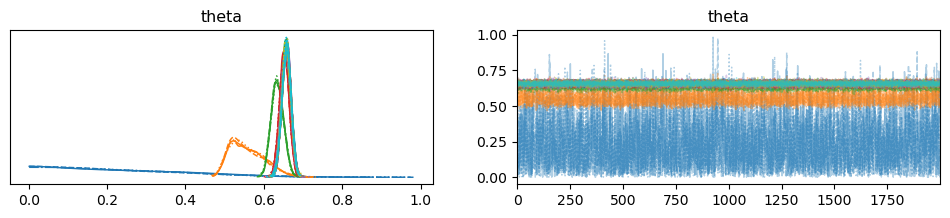

           mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
theta[0]   0.24  0.17    0.00     0.54        0.0      0.0   3500.41   
theta[1]   0.56  0.04    0.49     0.64        0.0      0.0   3579.64   
theta[2]   0.63  0.02    0.61     0.66        0.0      0.0   4632.47   
theta[3]   0.65  0.01    0.63     0.67        0.0      0.0   7366.34   
theta[4]   0.66  0.01    0.63     0.68        0.0      0.0   9743.16   
theta[5]   0.66  0.01    0.64     0.68        0.0      0.0   8045.82   
theta[6]   0.66  0.01    0.64     0.68        0.0      0.0   8063.58   
theta[7]   0.66  0.01    0.64     0.68        0.0      0.0   8660.46   
theta[8]   0.66  0.01    0.63     0.68        0.0      0.0   8814.38   
theta[9]   0.66  0.01    0.64     0.68        0.0      0.0   9045.14   
theta[10]  0.66  0.01    0.64     0.68        0.0      0.0   8283.56   
theta[11]  0.66  0.01    0.63     0.68        0.0      0.0   9818.68   
theta[12]  0.66  0.01    0.64     0.68        0.0      0.0   822

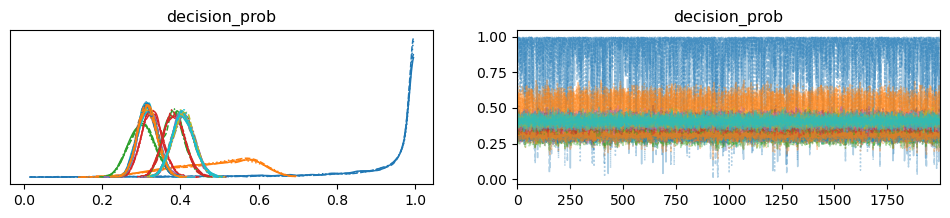

In [3]:
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd

# Observed data
#trust_levels = np.array([23.0, 45.0, 67.0, 89.0, 34.0, 56.0, 78.0, 12.0, 90.0, 22.0]) / 100
#decisions = np.array([0, 0, 1, 1, 0, 0, 1, 0, 1, 0])


# Load the CSV file
file_path = '/Users/apple/Documents/Fall_2024_Research/1009_event_hardcoded_07_19_2024.csv'  
data = pd.read_csv(file_path)
data = data.head(20)
# Extract column
trust_levels = data['trust_level'].values / 100  # Scale by dividing by 100
decisions = data['move_approved'].values
current_health = data['current_health'].values
proposed_damage = data['proposed_damage'].values

#length
N = len(trust_levels)

#model
with pm.Model() as model:
    sigma_theta = 0.05  # Standard deviation for theta evolution

    # Initial threshold prior
    theta_0 = pm.Beta('theta_0', alpha=1, beta=1)

    # Develop a theta list (since theta_t is a time series variable)
    theta_list = [theta_0]

    # Evolving `theta_t` with constraints to stay within [0, 1]
    for t in range(1, N):
        # Propose a new theta_t with normal evolution, then map it to [0, 1] using the sigmoid
        theta_proposed = pm.Normal(f'theta_proposed_{t}', mu=theta_list[t-1], sigma=sigma_theta)
        theta_t = pm.Deterministic(f'theta_{t}', pm.math.sigmoid(theta_proposed))
        theta_list.append(theta_t)

    # Convert theta list to a deterministic variable
    theta = pm.Deterministic('theta', pm.math.stack(theta_list))

    # Trust level condition (0 - 1)
    trust_condition_prob = pm.math.sigmoid((trust_levels - theta) * 10)

    # Health condition (0 or 1)
    health_condition = (current_health > proposed_damage).astype(float)
    print("health condition",health_condition)
    
    # The probability of the decision being approved is the AND of both conditions
    decision_prob = pm.Deterministic('decision_prob', trust_condition_prob * health_condition)
    print("decision", decision_prob.eval())
    
    # Model the observed decisions as Bernoulli outcomes using decision_prob as probability
    observed = pm.Bernoulli('observed', p=decision_prob, observed=decisions)

    # Inference
    # trace contains the collection of parameters of samples drawn from the posterior distributions 
    # 2000 samples to draw from for posterior
    # 1000 samples for warm-up iterations (but are discarded afterwards)
    # 90 percent of samples are accepted
    trace = pm.sample(draws=2000, tune=1000, target_accept=0.9, return_inferencedata=True)


# Trace plot
az.plot_trace(trace, var_names=['theta'])
plt.show()

# Summary statistics
print(az.summary(trace, var_names=['theta'], round_to=2))

# Trace plot
az.plot_trace(trace, var_names=['decision_prob'])
plt.show()


